# Netback and the arb

Where does the marginal US Gulf cargo go? Over the 245 dates both routes cover, Tokyo
netted 10.67 USD/MMBtu against Rotterdam's 10.76, so Europe paid about 9 cents more,
and the decision flipped 38 times. Tokyo's destination price is the higher of the two,
but it gives back more than the difference in freight and Panama tolls.

In [1]:
import duckdb
import matplotlib.pyplot as plt

con = duckdb.connect("../data/lng.duckdb", read_only=True)
con.execute("SET TimeZone='UTC'")  # show instants in UTC, not in the laptop's zone


def sql(query):
    return con.execute(query).df()

panel = sql("SELECT * FROM netback_panel ORDER BY route, trade_date")
arb = sql("SELECT * FROM v_netback_arb ORDER BY trade_date")

## The two netbacks and the spread

A positive spread means Asia out-bids Europe for the marginal cargo. The spread is blank
where only one route has a price: the routes cover different spans, and comparing them
off different dates is how you get the sign wrong.

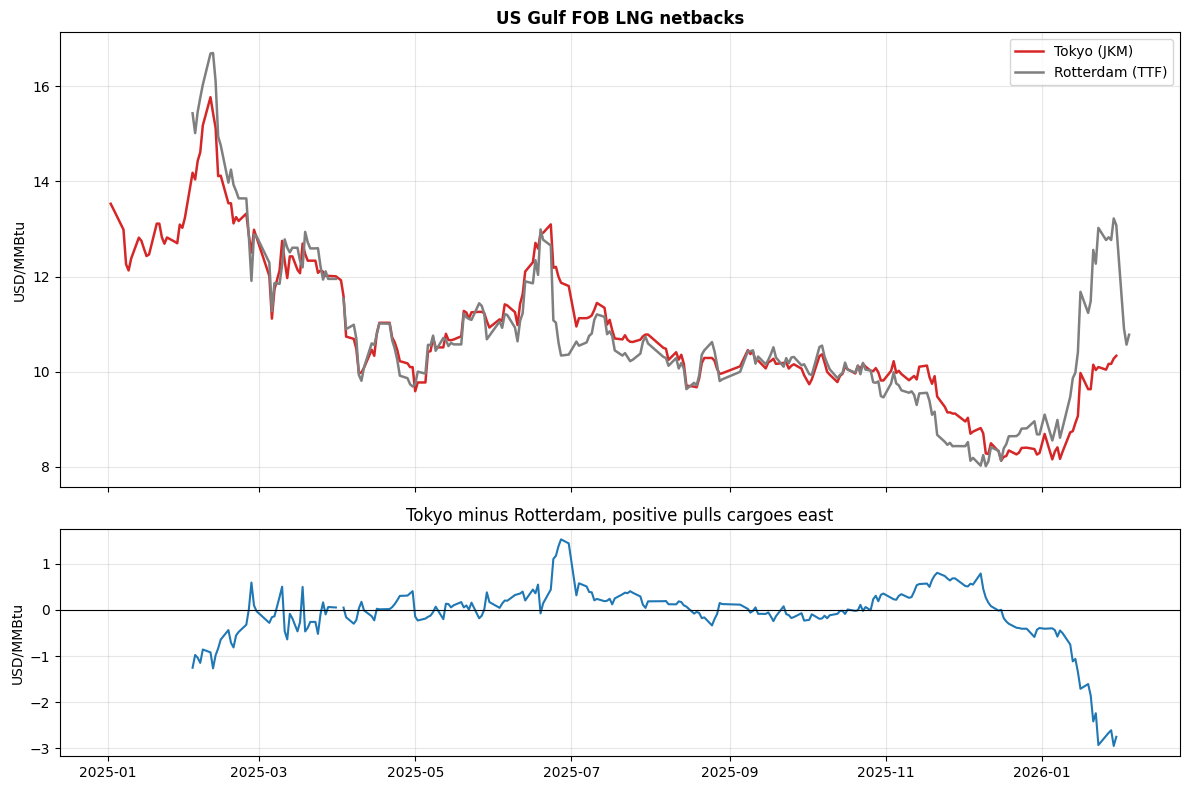

In [2]:
wide = panel.pivot(index="trade_date", columns="route", values="netback_usd_mmbtu")

fig, (top, bottom) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, height_ratios=[2, 1])
top.plot(wide.index, wide["us_gulf_to_tokyo"], color="tab:red", lw=1.8, label="Tokyo (JKM)")
top.plot(wide.index, wide["us_gulf_to_rotterdam"], color="tab:gray", lw=1.8, label="Rotterdam (TTF)")
top.set_title("US Gulf FOB LNG netbacks", fontweight="bold")
top.set_ylabel("USD/MMBtu")
top.legend()

bottom.plot(arb["trade_date"], arb["arb_usd_mmbtu"], color="tab:blue", lw=1.5)
bottom.axhline(0.0, color="black", lw=0.8)
bottom.set_title("Tokyo minus Rotterdam, positive pulls cargoes east")
bottom.set_ylabel("USD/MMBtu")

for ax in (top, bottom):
    ax.grid(True, alpha=0.3)
fig.tight_layout()

## Why the richer market can still lose

Means over the dates both routes cover. Tokyo's cargo sells for more, but it pays double
the sailing days, Panama tolls, and boil-off on twice the laden time. Rotterdam gives
back a regas fee instead, and that is the cheaper trade here.

In [3]:
common = wide.dropna().index
costs = [c for c in panel if c.endswith("_cost_usd_mmbtu")]

stack = (
    panel[panel["trade_date"].isin(common)]
    .groupby("route")[["dest_price_usd_mmbtu", *costs, "netback_usd_mmbtu"]]
    .mean()
    .round(3)
)
stack.T

route,us_gulf_to_rotterdam,us_gulf_to_tokyo
dest_price_usd_mmbtu,11.702,11.881
freight_cost_usd_mmbtu,0.220,0.517
boiloff_cost_usd_mmbtu,0.174,0.351
canal_cost_usd_mmbtu,0.000,0.286
port_cost_usd_mmbtu,0.057,0.057
regas_cost_usd_mmbtu,0.493,0.000
netback_usd_mmbtu,10.758,10.670


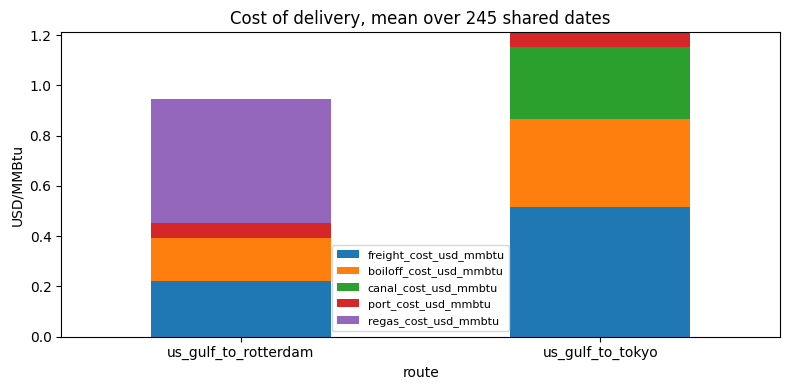

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
stack[costs].plot.bar(stacked=True, ax=ax, rot=0)
ax.set_ylabel("USD/MMBtu")
ax.set_title(f"Cost of delivery, mean over {len(common)} shared dates")
ax.legend(fontsize=8)
fig.tight_layout()

## Where each route stands now

The last date each route covers, which is not the same date: a February trade date needs
a JKM April contract the committed CSVs do not have.

In [5]:
sql("""
    WITH ranked AS (
        SELECT route, trade_date, dest_contract, freight_contract, netback_usd_mmbtu,
               max_staleness_days,
               ROW_NUMBER() OVER (PARTITION BY route ORDER BY trade_date DESC) AS recency
        FROM netback_panel
    )
    SELECT route, trade_date, dest_contract, freight_contract,
           ROUND(netback_usd_mmbtu, 3) AS netback_usd_mmbtu, max_staleness_days
    FROM ranked
    WHERE recency = 1
    ORDER BY route
""")

,route,trade_date,dest_contract,freight_contract,netback_usd_mmbtu,max_staleness_days
0,us_gulf_to_rotterdam,2026-02-04,TTFH2026,BLNG2H2026,10.777,1
1,us_gulf_to_tokyo,2026-01-30,JKMH2026,BLNG3G2026,10.334,0


## The days the decision changed

Every crossing of zero. These are the dates a cargo worth sending east on one day was
worth keeping in the Atlantic on the next, which is the only thing a routing desk acts
on.

In [6]:
sql("""
    WITH sequenced AS (
        SELECT trade_date, arb_usd_mmbtu,
               LAG(arb_usd_mmbtu) OVER (ORDER BY trade_date) AS previous
        FROM v_netback_arb
        WHERE arb_usd_mmbtu IS NOT NULL
    )
    SELECT trade_date,
           ROUND(previous, 3) AS previous_arb,
           ROUND(arb_usd_mmbtu, 3) AS arb_usd_mmbtu,
           CASE WHEN arb_usd_mmbtu > 0 THEN 'Asia' ELSE 'Europe' END AS now_pays_more
    FROM sequenced
    WHERE previous IS NOT NULL AND SIGN(previous) <> SIGN(arb_usd_mmbtu)
    ORDER BY trade_date
""").tail(10)

,trade_date,previous_arb,arb_usd_mmbtu,now_pays_more
28,2025-10-17,-0.086,0.011,Asia
29,2025-10-20,0.011,-0.019,Europe
30,2025-10-22,-0.007,0.111,Asia
31,2025-10-23,0.111,-0.020,Europe
32,2025-10-24,-0.020,0.064,Asia
33,2025-10-26,0.064,-0.006,Europe
34,2025-10-27,-0.006,0.234,Asia
35,2025-12-15,0.084,-0.013,Europe
36,2025-12-16,-0.013,0.004,Asia
37,2025-12-17,0.004,-0.177,Europe
